In [2]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_5cf9739858c069c4f3f513ed8f6e8884"

In [3]:
!pip install -q kaggle

In [4]:
!kaggle datasets download -d mashlyn/online-retail-ii-uci

Dataset URL: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
License(s): CC0-1.0
100% 14.5M/14.5M [00:00<00:00, 90.6MB/s]



In [5]:
!unzip -q online-retail-ii-uci.zip

In [6]:
!ls

online_retail_II.csv  online-retail-ii-uci.zip	sample_data


In [10]:
!ls

online_retail_II.csv  online-retail-ii-uci.zip	sample_data


In [11]:
import pandas as pd

df = pd.read_csv("online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [13]:
df.shape

(1067371, 8)

In [14]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [15]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object


# SaaS / E-Commerce Cohort Retention & CLTV Analysis

## Objective
This project analyzes customer retention using cohort analysis and estimates Customer Lifetime Value (CLTV). The goal is to identify customer churn patterns and provide actionable business recommendations to improve customer retention.

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

In [17]:
df = pd.read_csv("online_retail_II.csv")

In [18]:
df.shape

(1067371, 8)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [20]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [21]:
df.duplicated().sum()

np.int64(34335)

In [22]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [23]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [24]:
df = df.dropna(subset=["Customer ID"])

In [25]:
df = df[~df["Invoice"].astype(str).str.startswith("C")]

In [26]:
df = df[df["Quantity"] > 0]

In [27]:
df = df[df["Price"] > 0]

In [28]:
df = df.drop_duplicates()

In [29]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [30]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

In [31]:
cohort = (
    df.groupby("Customer ID")["InvoiceMonth"]
      .min()
)

df["CohortMonth"] = df["Customer ID"].map(cohort)

In [32]:
invoice_year = df["InvoiceMonth"].dt.year
invoice_month = df["InvoiceMonth"].dt.month

cohort_year = df["CohortMonth"].dt.year
cohort_month = df["CohortMonth"].dt.month

df["CohortIndex"] = (
    (invoice_year - cohort_year) * 12
    + (invoice_month - cohort_month)
    + 1
)

In [33]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,InvoiceMonth,CohortMonth,CohortIndex
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12,2009-12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009-12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009-12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12,2009-12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12,2009-12,1


In [34]:
df.to_csv("cleaned_online_retail.csv", index=False)

# Week 2: Cohort Retention Analysis

## Objective

The goal of this section is to analyze customer retention over time using cohort analysis. Customers are grouped based on the month of their first purchase (Cohort Month). By tracking how many customers return in subsequent months, we can identify retention trends, churn patterns, and opportunities to improve customer loyalty.

## 1. Calculate Cohort Sizes

Count the number of unique customers for each cohort and each month after acquisition.

In [35]:
cohort_data = (
    df.groupby(["CohortMonth", "CohortIndex"])["Customer ID"]
      .nunique()
      .reset_index(name="Customers")
)

cohort_data.head()

,CohortMonth,CohortIndex,Customers
0,2009-12,1,955
1,2009-12,2,337
2,2009-12,3,319
3,2009-12,4,406
4,2009-12,5,363


## 2. Build the Cohort Matrix

Transform the grouped data into a matrix where:

- Rows represent acquisition cohorts.
- Columns represent months since acquisition.
- Values represent the number of retained customers.

In [36]:
cohort_matrix = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Customers"
)

cohort_matrix

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,403.0,473.0,359.0,270.0,233.0,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,116.0,66.0,85.0,68.0,72.0,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,43.0,47.0,57.0,65.0,46.0,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,51.0,63.0,89.0,72.0,89.0,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,22.0,41.0,41.0,46.0,46.0,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,32.0,15.0,21.0,29.0,34.0,39.0,39.0,25.0,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,34.0,24.0,22.0,32.0,29.0,37.0,40.0,33.0,30.0,33.0,36.0,55.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,25.0,27.0,25.0,25.0,36.0,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,28.0,19.0,16.0,20.0,22.0,21.0,21.0,20.0,25.0,30.0,29.0,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Calculate Monthly Retention Rates

Retention rate is calculated by dividing the number of returning customers in each month by the number of customers in the first month of the cohort.

In [37]:
retention_matrix = cohort_matrix.divide(
    cohort_matrix.iloc[:, 0],
    axis=0
)

retention_matrix.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.352880,0.334031,0.425131,0.380105,0.359162,0.376963,0.342408,0.336126,0.362304,0.421990,0.495288,0.375916,0.282723,0.243979,0.302618,0.262827,0.302618,0.282723,0.259686,0.255497,0.315183,0.304712,0.407330,0.196859
2010-01,1.0,0.206266,0.310705,0.305483,0.263708,0.300261,0.258486,0.229765,0.279373,0.318538,0.302872,0.172324,0.221932,0.177546,0.187990,0.151436,0.234987,0.198433,0.185379,0.195822,0.242820,0.193211,0.245431,0.057441,NaN
2010-02,1.0,0.237968,0.224599,0.291444,0.245989,0.200535,0.192513,0.286096,0.254011,0.275401,0.114973,0.125668,0.152406,0.173797,0.122995,0.200535,0.160428,0.163102,0.144385,0.229947,0.229947,0.163102,0.058824,NaN,NaN
2010-03,1.0,0.189616,0.230248,0.241535,0.232506,0.203160,0.246050,0.302483,0.275395,0.108352,0.115124,0.142212,0.200903,0.162528,0.200903,0.169300,0.173815,0.155756,0.176072,0.200903,0.212190,0.079007,NaN,NaN,NaN
2010-04,1.0,0.193878,0.193878,0.163265,0.183673,0.224490,0.275510,0.261905,0.105442,0.108844,0.074830,0.139456,0.139456,0.156463,0.156463,0.156463,0.139456,0.149660,0.180272,0.224490,0.057823,NaN,NaN,NaN,NaN


In [38]:
retention_percentage = retention_matrix * 100
retention_percentage = retention_percentage.round(2)

retention_percentage

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,42.20,49.53,37.59,28.27,24.40,30.26,26.28,30.26,28.27,25.97,25.55,31.52,30.47,40.73,19.69
2010-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,30.29,17.23,22.19,17.75,18.80,15.14,23.50,19.84,18.54,19.58,24.28,19.32,24.54,5.74,NaN
2010-02,100.0,23.80,22.46,29.14,24.60,20.05,19.25,28.61,25.40,27.54,11.50,12.57,15.24,17.38,12.30,20.05,16.04,16.31,14.44,22.99,22.99,16.31,5.88,NaN,NaN
2010-03,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,10.84,11.51,14.22,20.09,16.25,20.09,16.93,17.38,15.58,17.61,20.09,21.22,7.90,NaN,NaN,NaN
2010-04,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,10.54,10.88,7.48,13.95,13.95,15.65,15.65,15.65,13.95,14.97,18.03,22.45,5.78,NaN,NaN,NaN,NaN
2010-05,100.0,15.75,16.93,17.32,17.72,25.59,21.26,12.60,5.91,8.27,11.42,13.39,15.35,15.35,9.84,12.60,13.78,16.54,15.35,4.72,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.41,18.89,20.37,22.96,28.52,12.59,8.89,8.15,11.85,10.74,13.70,14.81,12.22,11.11,12.22,13.33,20.37,5.19,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.59,18.28,29.57,29.03,13.98,11.29,14.52,14.52,11.29,13.44,14.52,13.44,13.44,19.35,17.20,23.66,8.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,20.37,29.63,32.10,17.28,11.73,9.88,12.35,13.58,12.96,12.96,12.35,15.43,18.52,17.90,19.75,6.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Cohort Retention Heatmap

The heatmap visualizes customer retention across different cohorts. Darker colors indicate stronger retention, while lighter colors indicate higher churn.

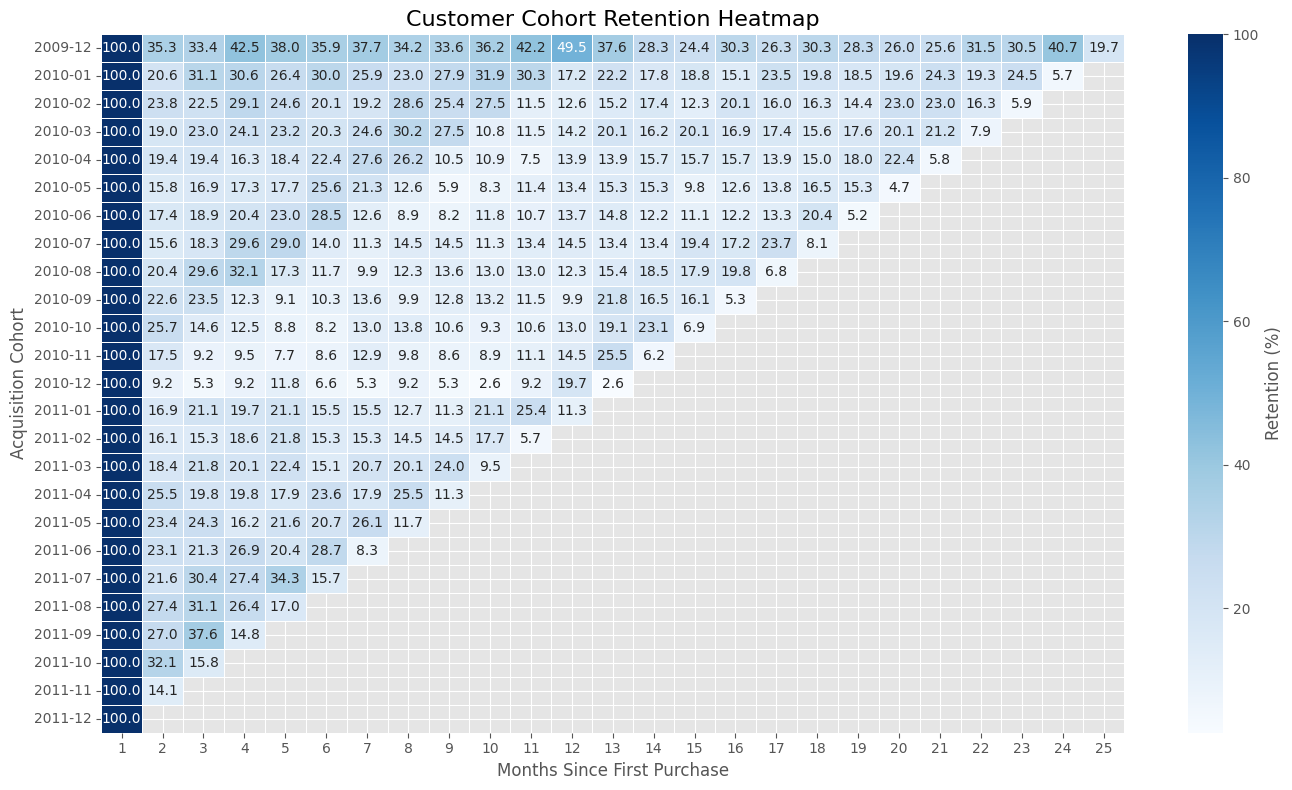

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_percentage,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Retention (%)"}
)

plt.title("Customer Cohort Retention Heatmap", fontsize=16)
plt.xlabel("Months Since First Purchase")
plt.ylabel("Acquisition Cohort")

plt.tight_layout()
plt.show()

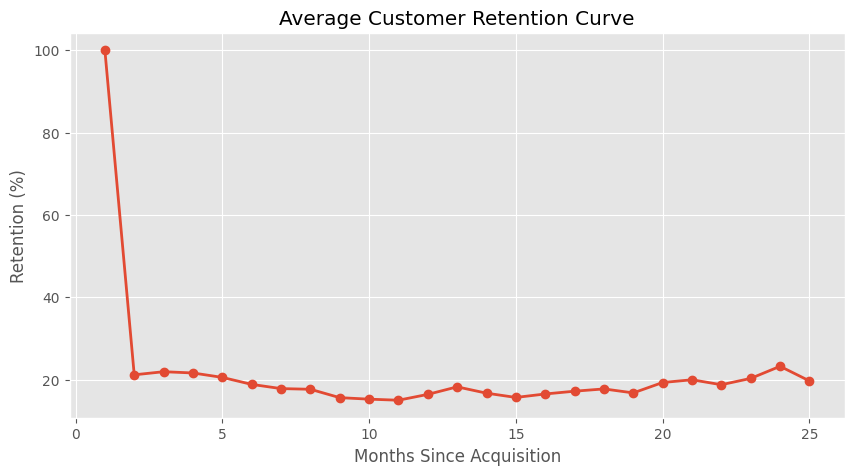

In [40]:
average_retention = retention_percentage.mean(axis=0)

plt.figure(figsize=(10, 5))

plt.plot(
    average_retention.index,
    average_retention.values,
    marker="o",
    linewidth=2
)

plt.title("Average Customer Retention Curve")
plt.xlabel("Months Since Acquisition")
plt.ylabel("Retention (%)")

plt.grid(True)

plt.show()

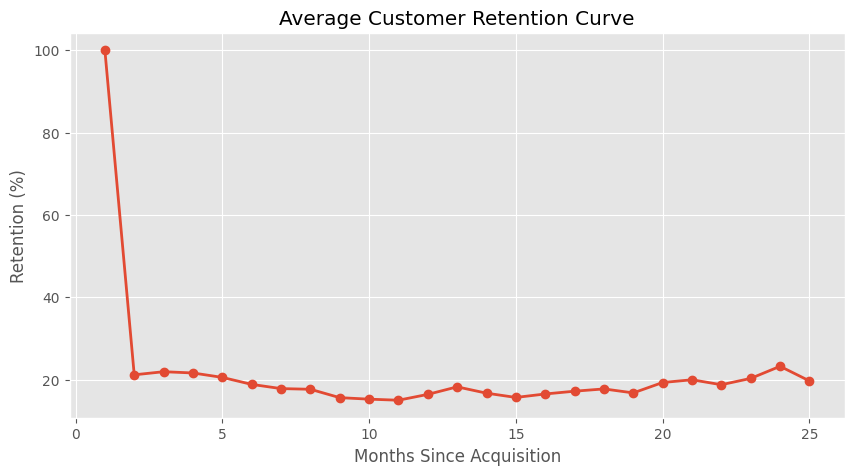

In [41]:
average_retention = retention_percentage.mean(axis=0)

plt.figure(figsize=(10, 5))

plt.plot(
    average_retention.index,
    average_retention.values,
    marker="o",
    linewidth=2
)

plt.title("Average Customer Retention Curve")
plt.xlabel("Months Since Acquisition")
plt.ylabel("Retention (%)")

plt.grid(True)

plt.show()

In [42]:
for i in range(len(average_retention) - 1):
    drop = average_retention.iloc[i] - average_retention.iloc[i + 1]
    print(f"Month {i+1} → Month {i+2}: {drop:.2f}% drop")

Month 1 → Month 2: 78.83% drop
Month 2 → Month 3: -0.76% drop
Month 3 → Month 4: 0.31% drop
Month 4 → Month 5: 1.07% drop
Month 5 → Month 6: 1.70% drop
Month 6 → Month 7: 1.02% drop
Month 7 → Month 8: 0.16% drop
Month 8 → Month 9: 2.04% drop
Month 9 → Month 10: 0.37% drop
Month 10 → Month 11: 0.26% drop
Month 11 → Month 12: -1.42% drop
Month 12 → Month 13: -1.83% drop
Month 13 → Month 14: 1.53% drop
Month 14 → Month 15: 1.04% drop
Month 15 → Month 16: -0.84% drop
Month 16 → Month 17: -0.68% drop
Month 17 → Month 18: -0.55% drop
Month 18 → Month 19: 0.97% drop
Month 19 → Month 20: -2.52% drop
Month 20 → Month 21: -0.66% drop
Month 21 → Month 22: 1.20% drop
Month 22 → Month 23: -1.53% drop
Month 23 → Month 24: -2.94% drop
Month 24 → Month 25: 3.54% drop


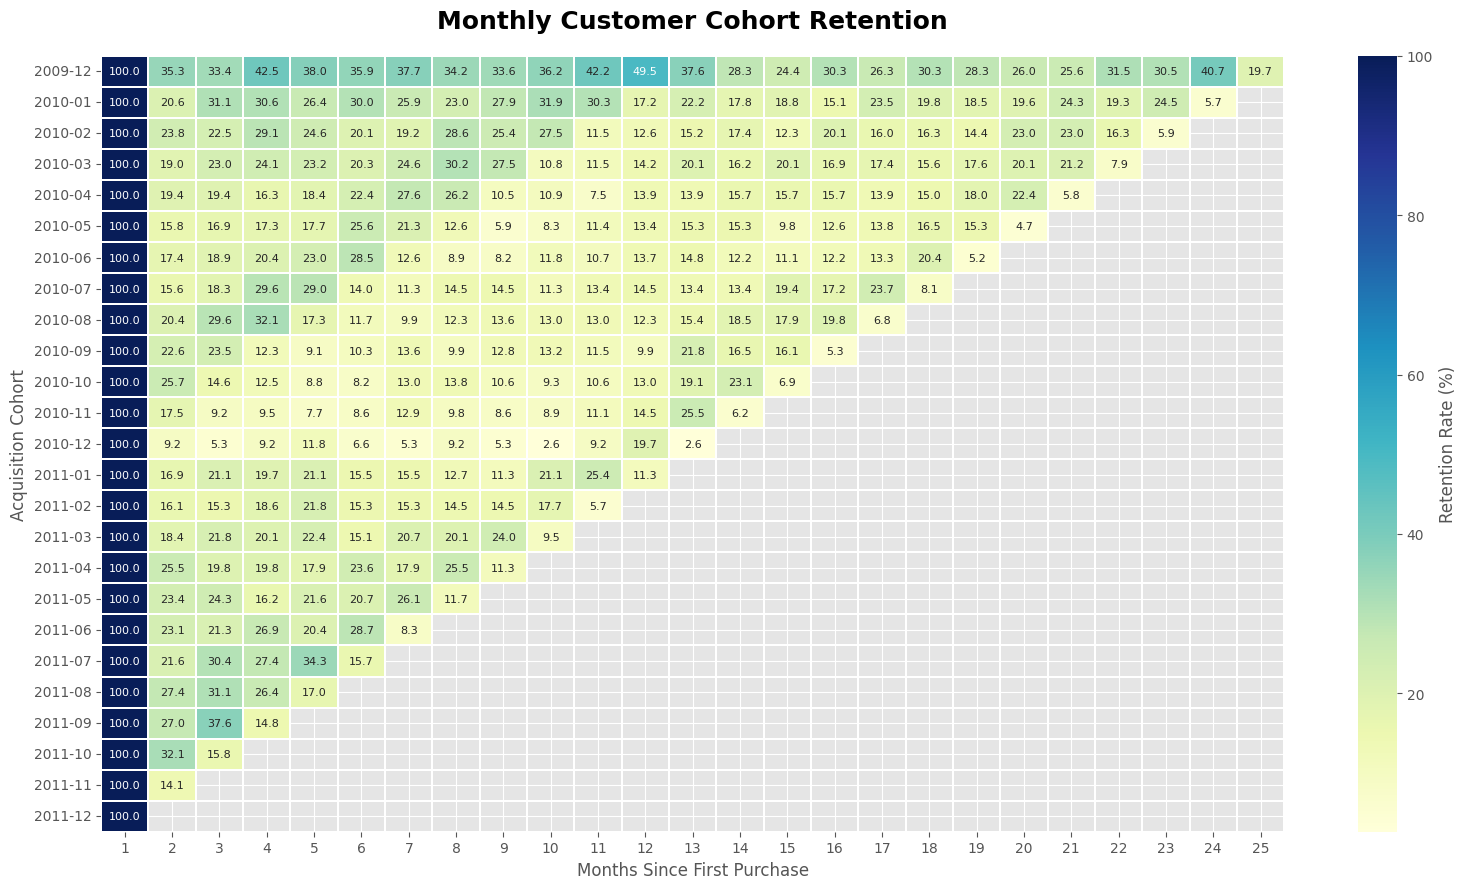

In [44]:
plt.figure(figsize=(16, 9))

sns.heatmap(
    retention_percentage,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Retention Rate (%)"},
    annot_kws={"size": 8}
)

plt.title(
    "Monthly Customer Cohort Retention",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Months Since First Purchase", fontsize=12)
plt.ylabel("Acquisition Cohort", fontsize=12)

plt.tight_layout()
plt.show()

## Key Business Insights

### Customer Retention

- Every cohort starts with a 100% retention rate in Month 1 because it represents each customer's first purchase.
- The most significant customer churn occurs between Month 1 and Month 2.
- Most cohorts retain approximately 15%–35% of customers after the first month.
- A small group of loyal customers continues purchasing for more than 12 months, indicating strong long-term customer value.

### Cohort Behaviour

- Earlier cohorts (2009–2010) display longer customer lifecycles because more follow-up data is available.
- Recent cohorts have fewer observable months due to the dataset's time window.

### Business Recommendations

- Improve the first 30-day customer experience through onboarding campaigns and personalized offers.
- Launch automated email or SMS reminders before the second month to reduce early churn.
- Introduce a loyalty or rewards program for repeat customers.
- Analyze the purchasing behavior of long-retained customers to identify traits shared by high-value users.

In [46]:
import os

os.makedirs("images", exist_ok=True)

In [47]:
plt.savefig("images/retention_heatmap.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [48]:
plt.savefig("images/retention_curve.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>